#**Imports**

In [1]:
# Standard Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics & Utilities
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')


#**Load Dataset**

In [2]:
df = pd.read_csv("/content/Historical Product Demand.csv")

In [3]:
df.shape

(1048575, 5)

In [4]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


#**Initial Inspection**

In [5]:
df.describe(include="all")

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
count,1048575,1048575,1048575,1037336,1048575
unique,2160,4,33,1729,3828
top,Product_1359,Whse_J,Category_019,2013/9/27,1000
freq,16936,764447,481099,2075,112682


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1048575 non-null  object
 1   Warehouse         1048575 non-null  object
 2   Product_Category  1048575 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1048575 non-null  object
dtypes: object(5)
memory usage: 40.0+ MB


In [7]:
df.isnull().sum()

,0
Product_Code,0
Warehouse,0
Product_Category,0
Date,11239
Order_Demand,0


In [8]:
df.duplicated().sum()

np.int64(122423)

#**Data Cleaning**

In [9]:
#Clean data column
df['Date'] = pd.to_datetime(df['Date'], errors="coerce", dayfirst=True)

#Clean Order Demand (handle parentheses/strings/negative)
df['Order_Demand'] = (df['Order_Demand']
                      .astype(str)
                      .str.replace(r'[(),]', '', regex=True)
                      .str.strip()
)

#convert to numeric safely
df['Order_Demand'] = pd.to_numeric(df['Order_Demand'], errors='coerce')

#Remove invalid rows (critical missing values only)
df = df.dropna(subset=['Date', 'Order_Demand'])

#removel duplicate after cleaning
df = df.drop_duplicates()

#sort date by time  (important for forcasting)
df = df.sort_values(by='Date')

#Reset index after cleaning
df = df.reset_index(drop=True)







In [10]:
df.shape

(922816, 5)

In [11]:
df.isnull().sum()

,0
Product_Code,0
Warehouse,0
Product_Category,0
Date,0
Order_Demand,0


In [12]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0965,Whse_A,Category_006,2011-01-08,2
1,Product_1724,Whse_A,Category_003,2011-05-31,108
2,Product_1521,Whse_S,Category_019,2011-06-24,85000
3,Product_1521,Whse_S,Category_019,2011-06-24,7000
4,Product_1507,Whse_C,Category_019,2011-09-02,1250


#**Exploratory Data Analysis (Visualizations)**

Dataset Shape: (922816, 5)


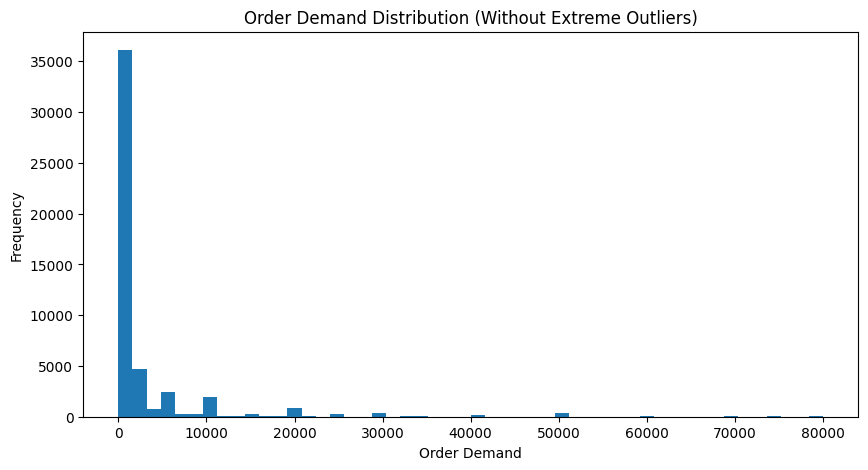

In [13]:
print("Dataset Shape:", df.shape)

# 1. Order Demand Distribution
plt.figure(figsize=(10, 5))

# Sample data for better performance and visualization
sample_data = df["Order_Demand"].sample(50000, random_state=42)

# Limit to 99th percentile to remove extreme outliers
upper_limit = sample_data.quantile(0.99)
sample_data = sample_data[sample_data <= upper_limit]

# Plot histogram
plt.hist(sample_data, bins=50)

# Titles and labels
plt.title("Order Demand Distribution (Without Extreme Outliers)")
plt.xlabel("Order Demand")
plt.ylabel("Frequency")

plt.show()

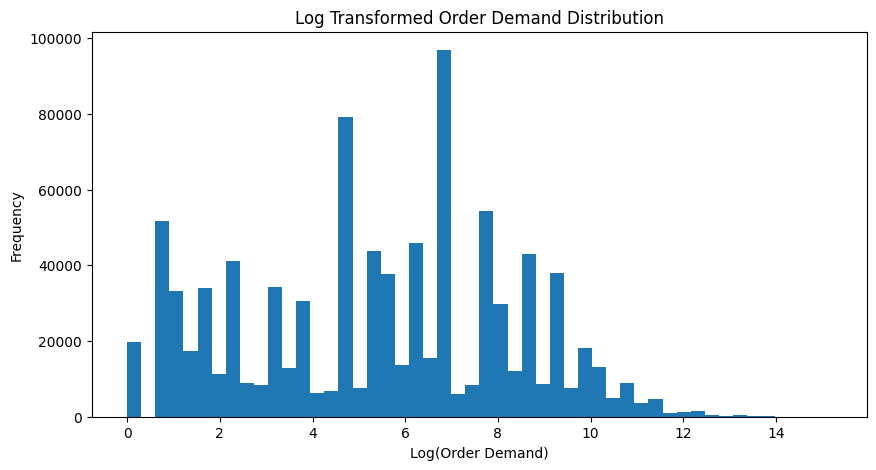

In [14]:
# 2. Log Transformation Plot

plt.figure(figsize=(10,5))
log_demand = np.log1p(df["Order_Demand"])
plt.hist(log_demand, bins=50)
plt.title("Log Transformed Order Demand Distribution")
plt.xlabel("Log(Order Demand)")
plt.ylabel("Frequency")
plt.show()

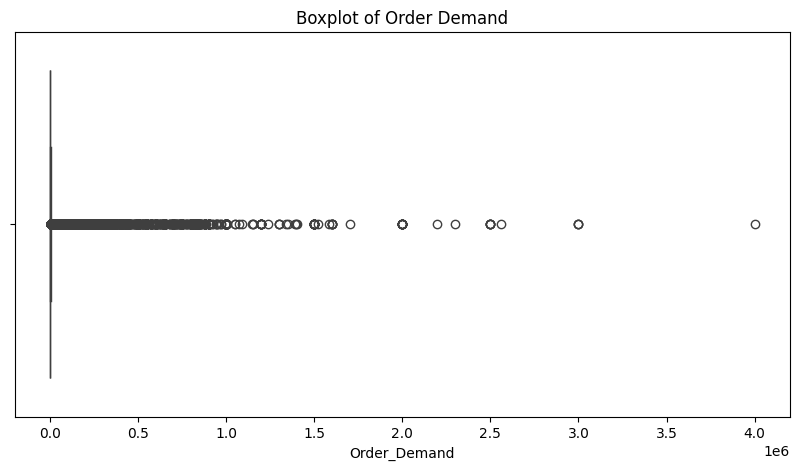

In [15]:

# 3. Boxplot for Outlier Detection

plt.figure(figsize=(10,5))
sns.boxplot(x=df["Order_Demand"])
plt.title("Boxplot of Order Demand")
plt.show()

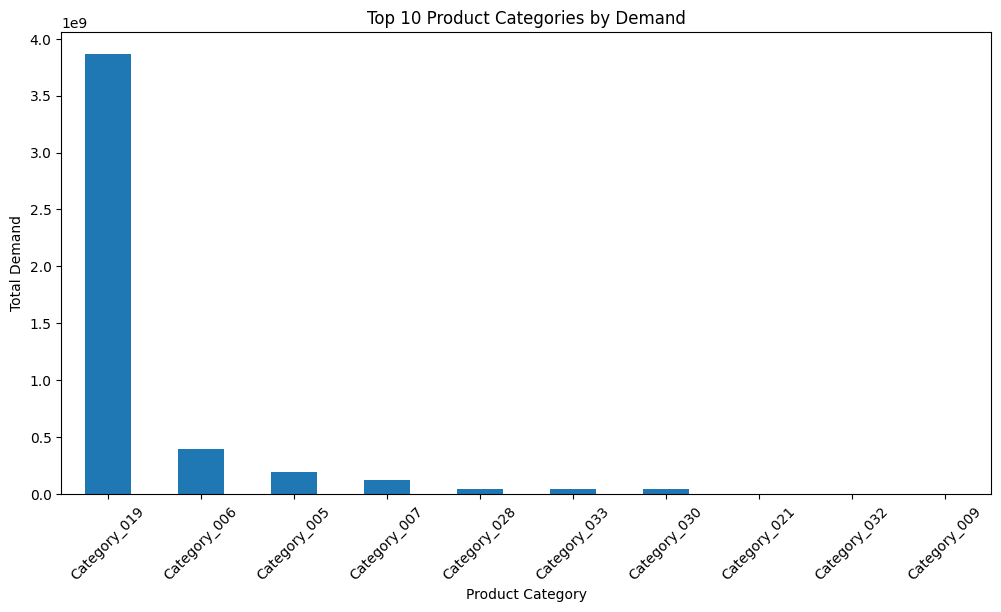

In [16]:
# 4. Product Category-wise Demand

category_demand = df.groupby("Product_Category")["Order_Demand"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
category_demand.head(10).plot(kind="bar")
plt.title("Top 10 Product Categories by Demand")
plt.xlabel("Product Category")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.show()

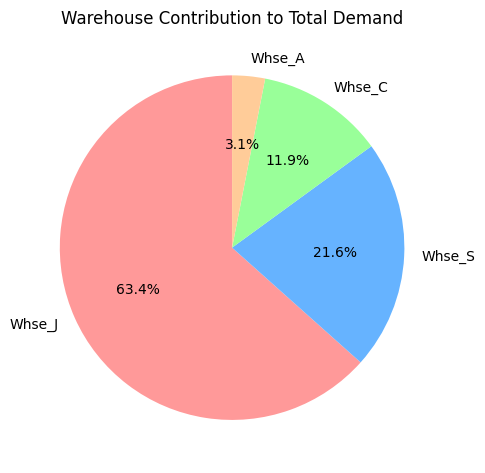

In [17]:
# 5. Pie Chart of Warehouse Share
warehouse_demand = df.groupby("Warehouse")["Order_Demand"].sum().sort_values(ascending=False)
plt.figure(figsize=(5,5))

warehouse_demand.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["#ff9999","#66b3ff","#99ff99","#ffcc99"]
)

plt.title("Warehouse Contribution to Total Demand")
plt.ylabel("")
plt.tight_layout()
plt.show()

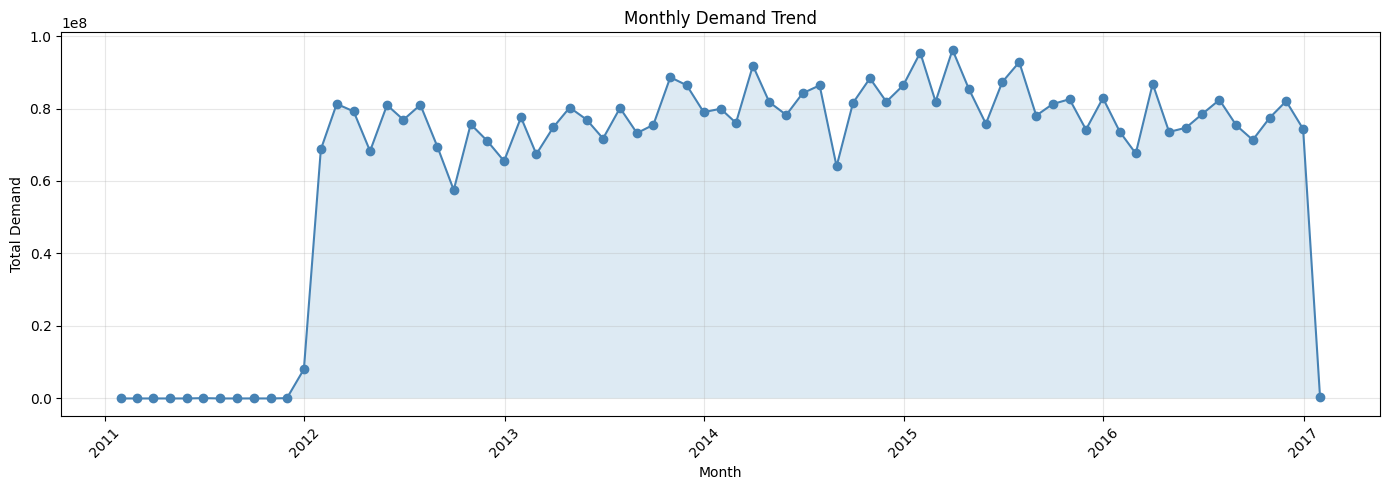

In [18]:
# 6. Monthly Demand Trend
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

monthly = df.resample("M", on="Date")["Order_Demand"].sum()

plt.figure(figsize=(14,5))
plt.plot(monthly.index, monthly.values, marker="o", color="steelblue")
plt.fill_between(monthly.index, monthly.values, alpha=0.15)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

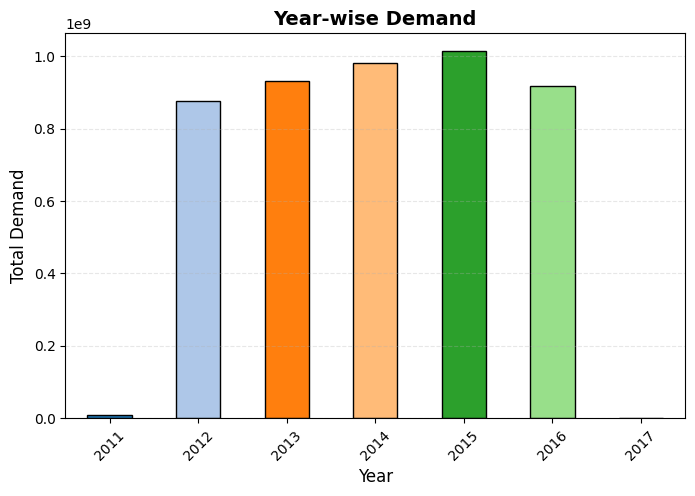

In [19]:
# 7. Year-wise Demand

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Create Year column (FIX)
df["Year"] = df["Date"].dt.year

# Group by Year
yearly_demand = df.groupby("Year")["Order_Demand"].sum()

plt.figure(figsize=(8, 5))

# Distinct colors
colors = plt.cm.tab20(range(len(yearly_demand)))

yearly_demand.plot(
    kind="bar",
    color=colors,
    edgecolor="black"
)

plt.title("Year-wise Demand", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Demand", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

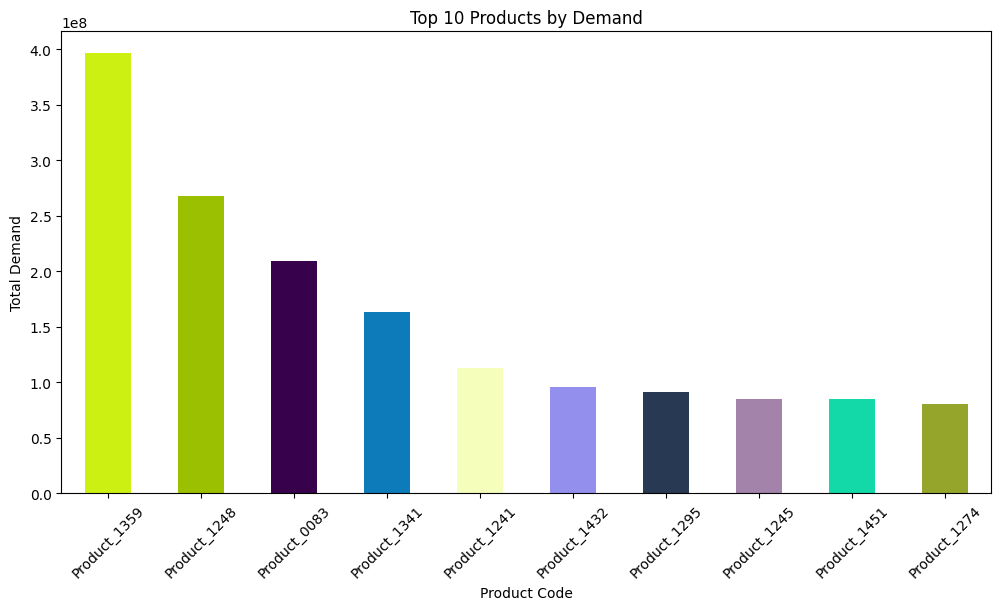

In [20]:
# 8. Top 10 Products by Demand

top_products = (
    df.groupby("Product_Code")["Order_Demand"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
colors = np.random.rand(len(top_products), 3)

plt.figure(figsize=(12,6))
top_products.plot(kind="bar", color=colors)

plt.title("Top 10 Products by Demand")
plt.xlabel("Product Code")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.show()

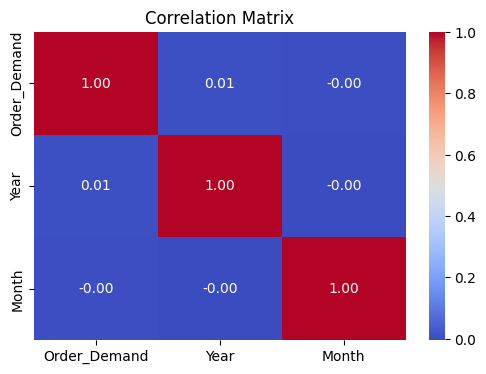

In [21]:
# 9. Correlation Matrix

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Create missing columns (FIX)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

# Select numeric data safely
numeric_df = df[["Order_Demand", "Year", "Month"]]

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

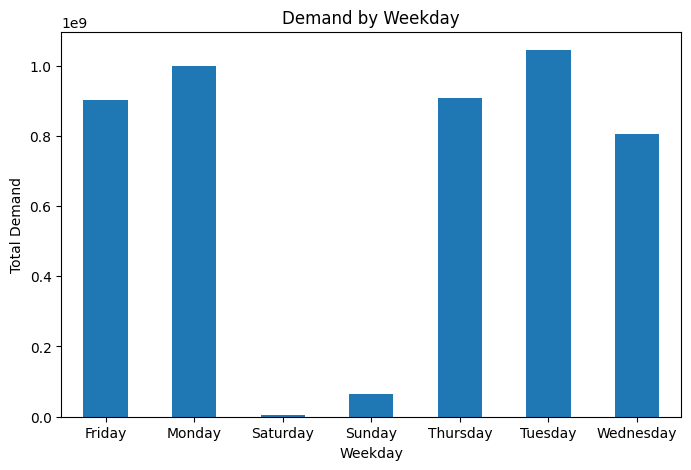

In [22]:
# 10. Demand by Weekday

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Weekday"] = df["Date"].dt.day_name()


weekday_demand = df.groupby("Weekday")["Order_Demand"].sum()

plt.figure(figsize=(8,5))
weekday_demand.plot(kind="bar")

plt.title("Demand by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Total Demand")

plt.xticks(rotation=0)
plt.show()

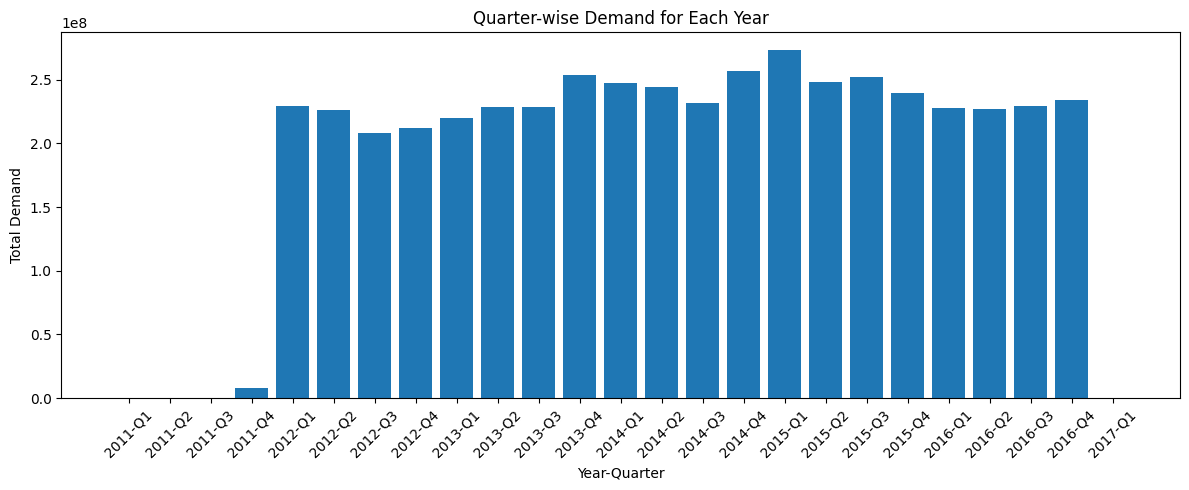

In [23]:
# 11. Quarter-wise Demand

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Year"] = df["Date"].dt.year
df["Quarter"] = "Q" + df["Date"].dt.quarter.astype(str)

quarter_year_demand = df.groupby(["Year", "Quarter"])["Order_Demand"].sum().reset_index()

# Create label for plotting
quarter_year_demand["Year_Quarter"] = quarter_year_demand["Year"].astype(str) + "-" + quarter_year_demand["Quarter"]

plt.figure(figsize=(12,5))
plt.bar(
    quarter_year_demand["Year_Quarter"],
    quarter_year_demand["Order_Demand"]
)

plt.title("Quarter-wise Demand for Each Year")
plt.xlabel("Year-Quarter")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#**Feature Engineering**

In [24]:

df = df.sort_values("Date")

# Time-based features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.weekday
df["Quarter"] = df["Date"].dt.quarter

# Cyclical encoding (IMPORTANT improvement)
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

df["Weekday_sin"] = np.sin(2 * np.pi * df["Weekday"] / 7)
df["Weekday_cos"] = np.cos(2 * np.pi * df["Weekday"] / 7)

# Lag features (CRITICAL for forecasting)
df["lag_1"] = df["Order_Demand"].shift(1)
df["lag_7"] = df["Order_Demand"].shift(7)
df["lag_30"] = df["Order_Demand"].shift(30)

# Rolling statistics
df["rolling_mean_7"] = df["Order_Demand"].rolling(7).mean()
df["rolling_std_7"] = df["Order_Demand"].rolling(7).std()

# Drop rows created by lagging
df = df.dropna().reset_index(drop=True)

#**Encoding Categorical Features**

In [25]:
for col in ["Product_Code", "Warehouse", "Product_Category"]:
    df[col] = df[col].astype("category").cat.codes

#**Model Preparation**

In [26]:
df = df.sort_values("Date")

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(columns=["Order_Demand", "Date"])
y_train = train["Order_Demand"]

X_test = test.drop(columns=["Order_Demand", "Date"])
y_test = test["Order_Demand"]

print(X_train.shape, X_test.shape)

(738228, 17) (184558, 17)


#**Multiple Machine Learning Models**

In [29]:
model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Linear Regression")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression
MAE: 7565.840239917424
RMSE: 29203.00202776701
R2 Score: 0.17059256817122603


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = DecisionTreeRegressor(
    max_depth=12,
    min_samples_split=10,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Decision Tree Regressor")
print("-----------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(
    n_estimators=10,
    max_depth=8,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)


# Evaluation
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Random Forest Regressor")
print("-----------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Random Forest Regressor
-----------------------
MAE: 4895.360727135046
RMSE: 19418.197611122312
R2 Score: 0.63328324067471


In [33]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# XGBoost Model
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train model
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

# Results
print("XGBoost Regressor")
print("-----------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

XGBoost Regressor
-----------------
MAE: 4819.58837890625
RMSE: 19215.659447440255
R2 Score: 0.640893280506134


#**Best Model**

In [35]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        29203.0020,
        19600.5491,
        19418.1976,
        19215.6594
    ]
})

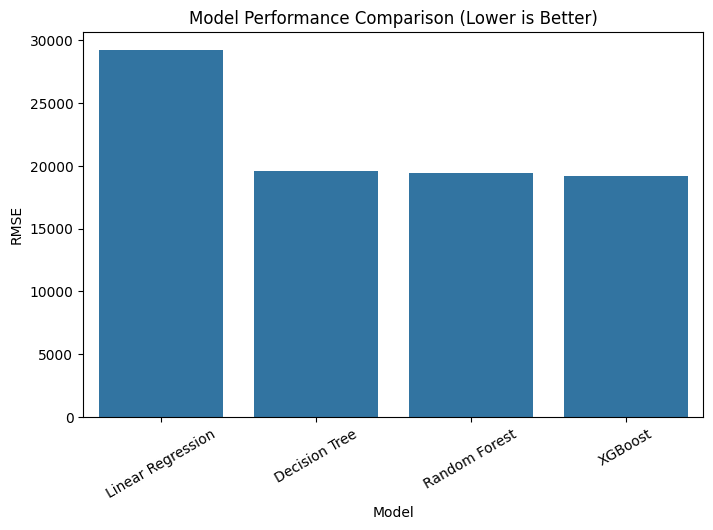

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE"
)

plt.title("Model Performance Comparison (Lower is Better)")
plt.xticks(rotation=30)

plt.show()

#**Saving the mode**

In [37]:
# Save Best Model

import joblib

# Best model based on lowest RMSE
best_model_name = "XGBoost"

print("Best Model:", best_model_name)

# 'model' variable currently contains the last trained model.
# So retrain XGBoost before saving it.

best_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train XGBoost
best_model.fit(X_train, y_train)

# Save model
joblib.dump(
    best_model,
    "best_demand_forecasting_model.pkl"
)

print("Best model saved successfully as 'best_demand_forecasting_model.pkl'")

Best Model: XGBoost
Best model saved successfully as 'best_demand_forecasting_model.pkl'
